ARTI308 - Machine Learning
# Seaborn Overview

Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics.




## Distribution Plots

Let's discuss some plots that allow us to visualize the distribution of a data set. These plots are:

* distplot
* jointplot
* pairplot
* rugplot
* kdeplot

## Imports

In [2]:
import seaborn as sns    # Import statistical data visualization library
%matplotlib inline      #Show Seaborn plots directly in the notebook

UsageError: unrecognized arguments: #Show Seaborn plots directly in the notebook


## Data
Seaborn comes with built-in data sets!

In [5]:
tips = sns.load_dataset('tips') # loads the dataset

In [6]:
tips.head() # first 5 rows of the dataset

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## distplot

The distplot shows the distribution of a univariate set of observations.

/tmp/ipykernel_8038/1093071496.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'])


<Axes: xlabel='total_bill', ylabel='Density'>

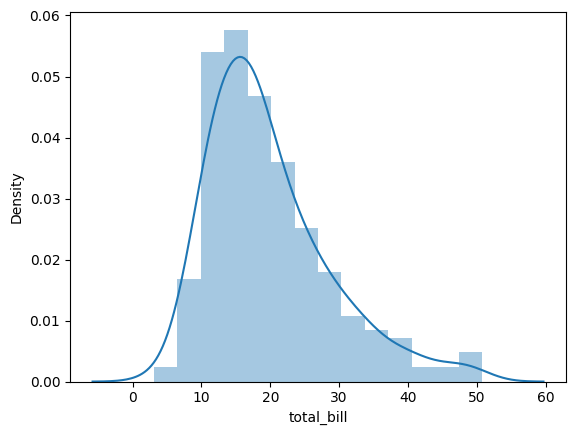

In [7]:
sns.distplot(tips['total_bill'])
# Safe to ignore warnings

To remove the kde layer and just have the histogram use:

/tmp/ipykernel_8038/1352048471.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(tips['total_bill'],kde=False,bins=30) # Plot 'total_bill' histogram with 30 bins and no KDE curve


<Axes: xlabel='total_bill'>

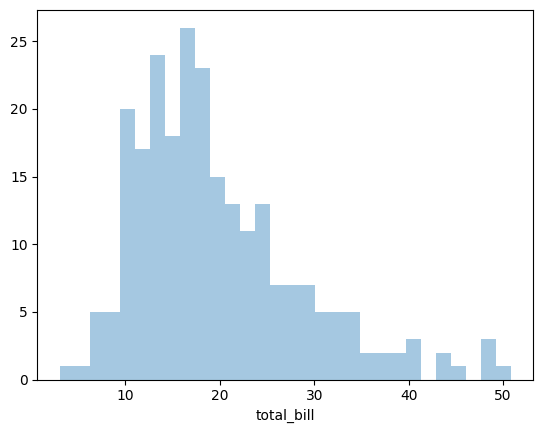

In [8]:
sns.distplot(tips['total_bill'],kde=False,bins=30) # Plot 'total_bill' histogram with 30 bins and no KDE curve

## jointplot

jointplot() allows you to basically match up two distplots for bivariate data. With your choice of what **kind** parameter to compare with: 
* “scatter” 
* “reg” 
* “resid” 
* “kde” 
* “hex”

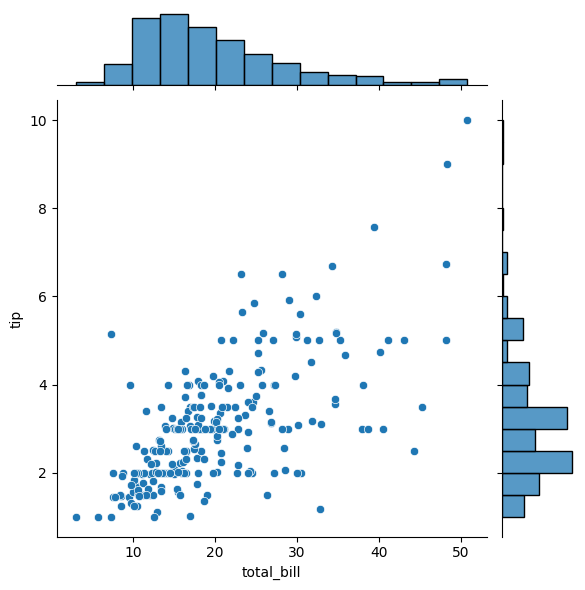

In [9]:
# Create a joint plot showing scatter and distribution of two variables
sns.jointplot(x='total_bill',y='tip',data=tips,kind='scatter')

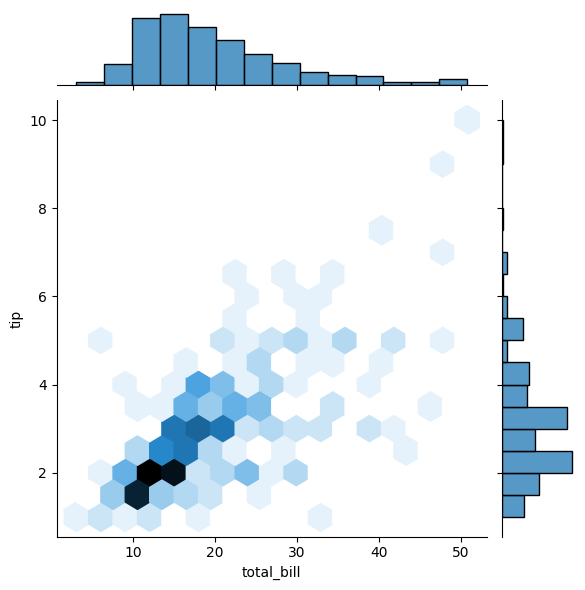

In [10]:
# Create a joint plot using hexagonal bins for density
sns.jointplot(x='total_bill',y='tip',data=tips,kind='hex')

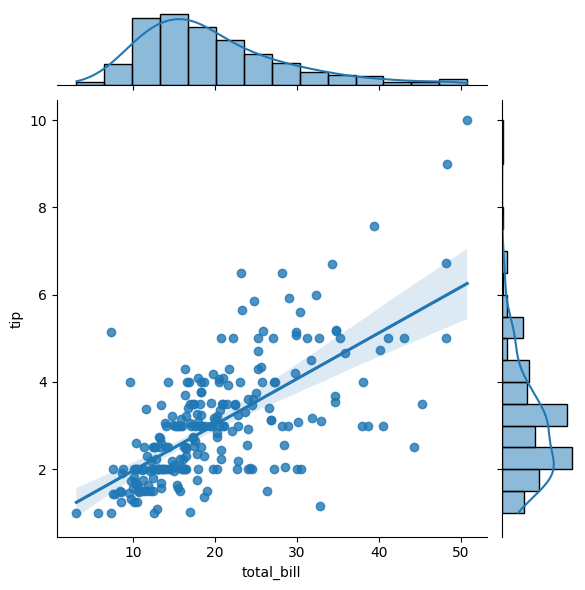

In [11]:
# Create a joint plot with a regression line and distribution curves
sns.jointplot(x='total_bill',y='tip',data=tips,kind='reg')

## pairplot

pairplot will plot pairwise relationships across an entire dataframe (for the numerical columns) and supports a color hue argument (for categorical columns). 

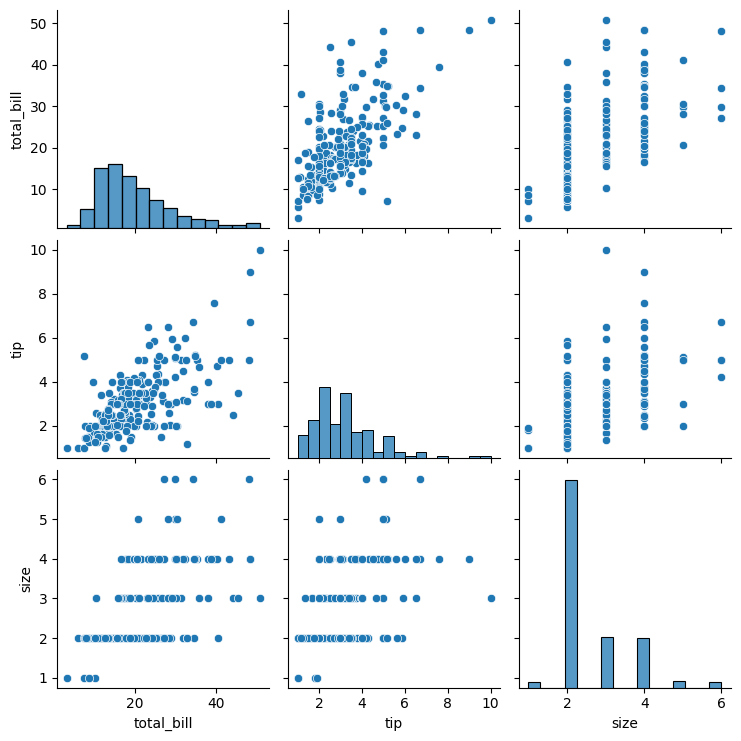

In [12]:
# Plot pairwise relationships on the dataset
sns.pairplot(tips)

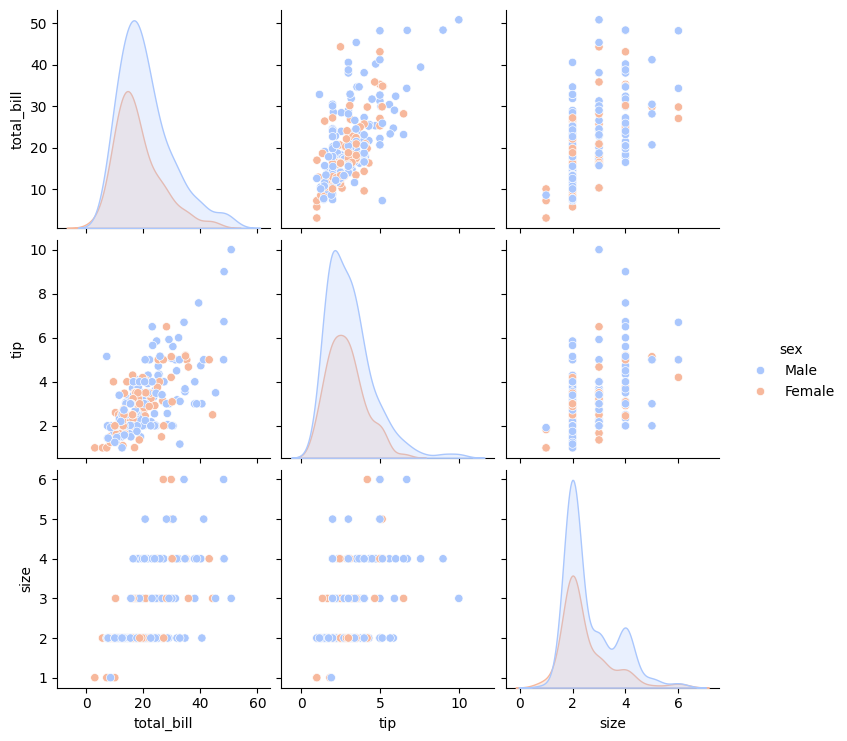

In [13]:
# Plot pairwise relationships
sns.pairplot(tips,hue='sex',palette='coolwarm')

## rugplot

rugplots are actually a very simple concept, they just draw a dash mark for every point on a univariate distribution. They are the building block of a KDE plot:

<Axes: xlabel='total_bill'>

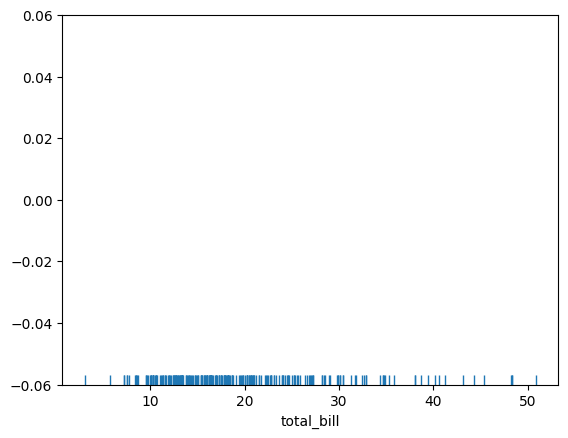

In [14]:
# Draw small vertical ticks at every data point on the x-axis
sns.rugplot(tips['total_bill'])

## kdeplot

kdeplots are [Kernel Density Estimation plots](http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth). These KDE plots replace every single observation with a Gaussian (Normal) distribution centered around that value. For example:

(0.0, 1.0)

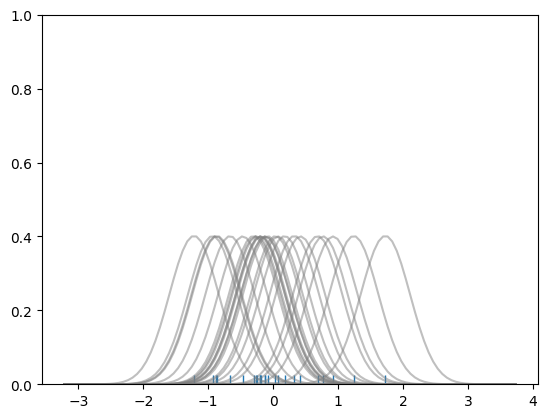

In [16]:
# Don't worry about understanding this code!
# It's just for the diagram below
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

#Create dataset
dataset = np.random.randn(25)

# Create another rugplot
sns.rugplot(dataset);

# Set up the x-axis for the plot
x_min = dataset.min() - 2
x_max = dataset.max() + 2

# 100 equally spaced points from x_min to x_max
x_axis = np.linspace(x_min,x_max,100)

# Set up the bandwidth, for info on this:
url = 'http://en.wikipedia.org/wiki/Kernel_density_estimation#Practical_estimation_of_the_bandwidth'

bandwidth = ((4*dataset.std()**5)/(3*len(dataset)))**.2


# Create an empty kernel list
kernel_list = []

# Plot each basis function
for data_point in dataset:
    
    # Create a kernel for each point and append to list
    kernel = stats.norm(data_point,bandwidth).pdf(x_axis)
    kernel_list.append(kernel)
    
    #Scale for plotting
    kernel = kernel / kernel.max()
    kernel = kernel * .4
    plt.plot(x_axis,kernel,color = 'grey',alpha=0.5)

plt.ylim(0,1)

Text(0.5, 0.98, 'Sum of the Basis Functions')

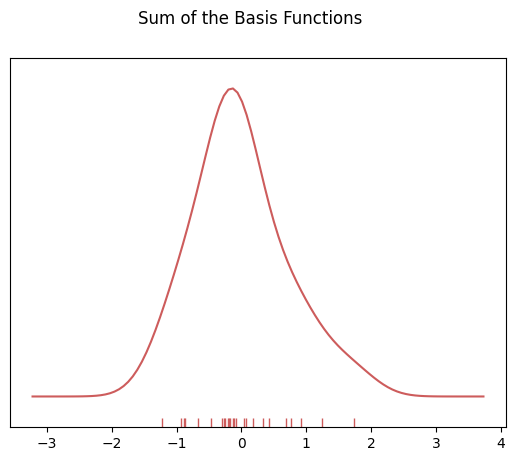

In [17]:
# To get the kde plot we can sum these basis functions.

# Plot the sum of the basis function
sum_of_kde = np.sum(kernel_list,axis=0)

# Plot figure
fig = plt.plot(x_axis,sum_of_kde,color='indianred')

# Add the initial rugplot
sns.rugplot(dataset,c = 'indianred')

# Get rid of y-tick marks
plt.yticks([])

# Set title
plt.suptitle("Sum of the Basis Functions")

So with our tips dataset:

<Axes: xlabel='total_bill', ylabel='Density'>

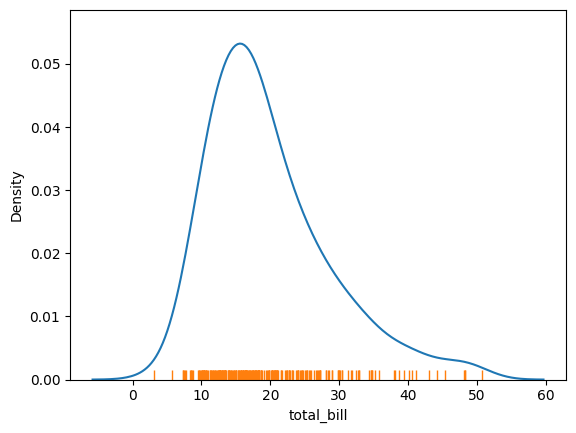

In [18]:
sns.kdeplot(tips['total_bill']) # Plot a smooth density curve
sns.rugplot(tips['total_bill'])  # Add marks for every data point

<Axes: xlabel='tip', ylabel='Density'>

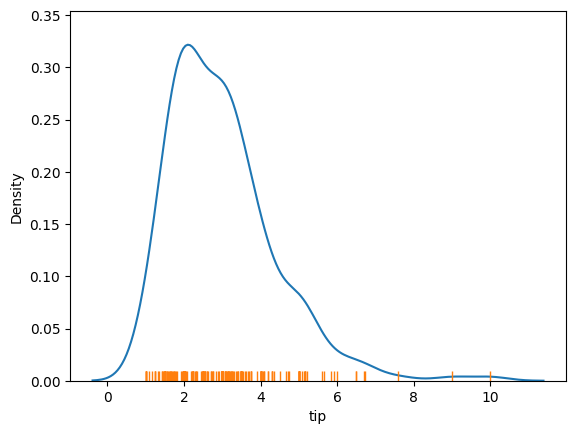

In [19]:
# Plot a smooth density curve for tips
sns.kdeplot(tips['tip'])
# Add small vertical ticks for each tip data point
sns.rugplot(tips['tip'])

# Categorical Data Plots

Now let's discuss using seaborn to plot categorical data! There are a few main plot types for this:

* factorplot
* boxplot
* violinplot
* stripplot
* swarmplot
* barplot
* countplot

Let's go through examples of each!

In [20]:
import seaborn as sns    # Load statistical viz library
%matplotlib inline      # Render plots directly in notebooks

UsageError: unrecognized arguments: # Render plots directly in notebooks


In [21]:
# Load the built in dataset
tips = sns.load_dataset('tips')
# Display the first 5 rows
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## barplot and countplot

These very similar plots allow you to get aggregate data off a categorical feature in your data. **barplot** is a general plot that allows you to aggregate the categorical data based off some function, by default the mean:

<Axes: xlabel='sex', ylabel='total_bill'>

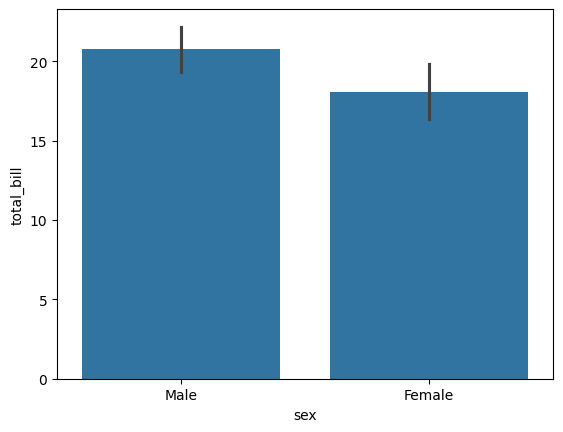

In [22]:
# Compare average total bill by sex
sns.barplot(x='sex', y='total_bill', data=tips)

In [23]:
import numpy as np # import np

You can change the estimator object to your own function, that converts a vector to a scalar:

<Axes: xlabel='sex', ylabel='total_bill'>

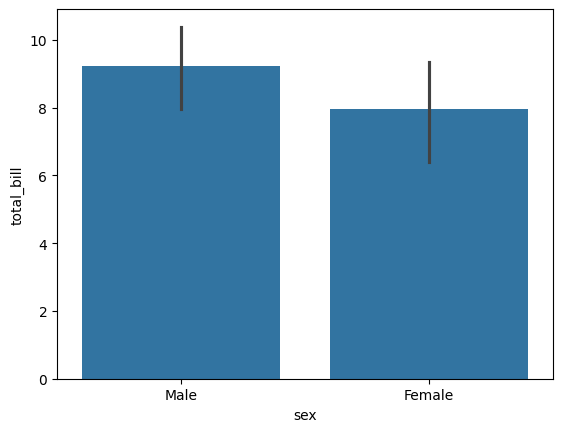

In [24]:
# Plot average total bill by sex using standard deviation as the estimator
sns.barplot(x='sex', y='total_bill', data=tips, estimator=np.std)

### countplot

This is essentially the same as barplot except the estimator is explicitly counting the number of occurrences. Which is why we only pass the x value:

<Axes: xlabel='sex', ylabel='count'>

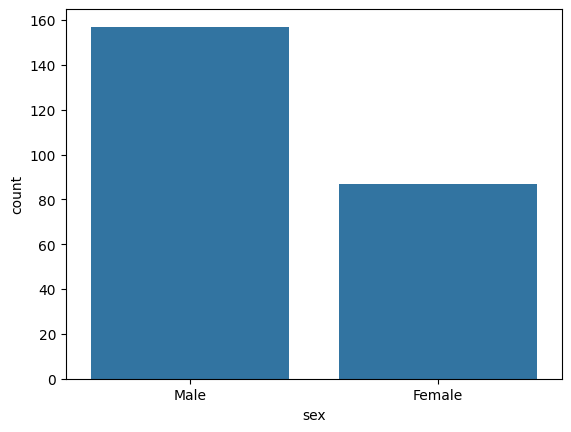

In [25]:
# Count occurrences for each category in 'sex'
sns.countplot(x='sex', data=tips)

## boxplot and violinplot

boxplots and violinplots are used to shown the distribution of categorical data. A box plot (or box-and-whisker plot) shows the distribution of quantitative data in a way that facilitates comparisons between variables or across levels of a categorical variable. The box shows the quartiles of the dataset while the whiskers extend to show the rest of the distribution, except for points that are determined to be “outliers” using a method that is a function of the inter-quartile range.

/tmp/ipykernel_8038/292002155.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow')


<Axes: xlabel='day', ylabel='total_bill'>

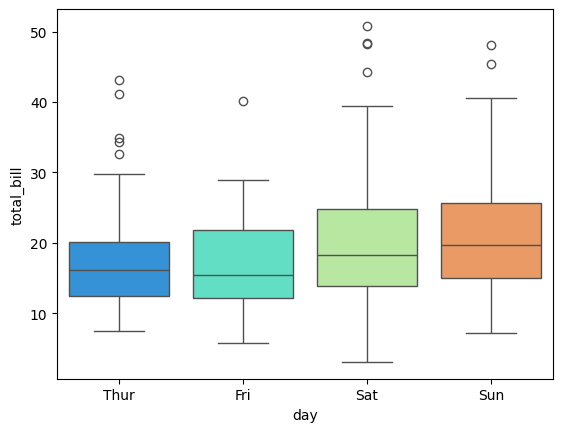

In [26]:
# Boxplot of total bill by day with rainbow colors
sns.boxplot(x="day", y="total_bill", data=tips,palette='rainbow')

<Axes: >

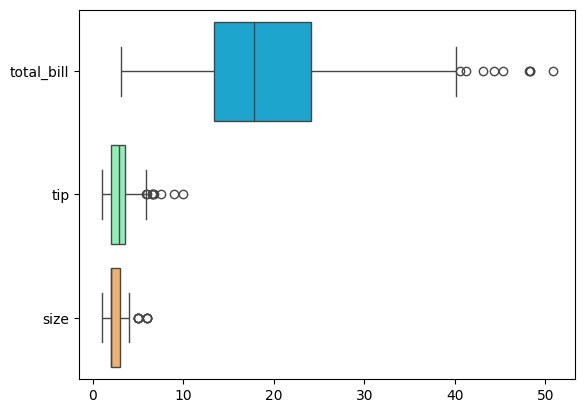

In [27]:
# Can do entire dataframe with orient='h'
sns.boxplot(data=tips,palette='rainbow',orient='h')

<Axes: xlabel='day', ylabel='total_bill'>

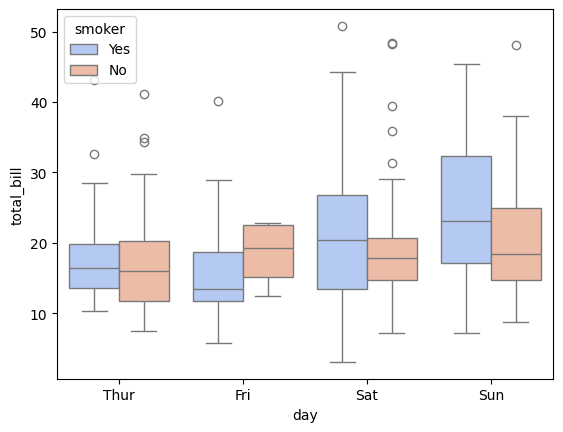

In [28]:
# Boxplot grouped by day and split by smoker status
sns.boxplot(x="day", y="total_bill", hue="smoker",data=tips, palette="coolwarm")

### violinplot
A violin plot plays a similar role as a box and whisker plot. It shows the distribution of quantitative data across several levels of one (or more) categorical variables such that those distributions can be compared. Unlike a box plot, in which all of the plot components correspond to actual datapoints, the violin plot features a kernel density estimation of the underlying distribution.

/tmp/ipykernel_8038/1252183689.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow') # Create violin plots to show data density


<Axes: xlabel='day', ylabel='total_bill'>

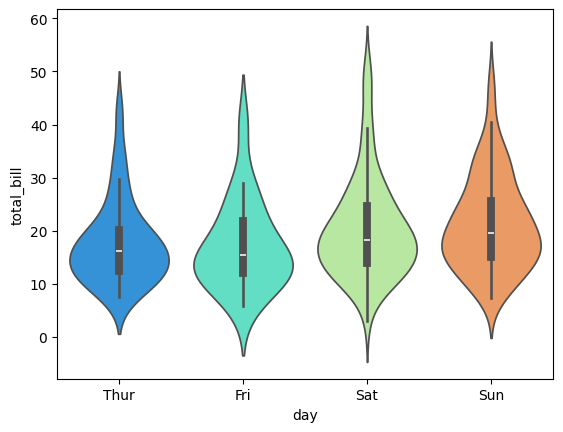

In [29]:
sns.violinplot(x="day", y="total_bill", data=tips,palette='rainbow') # Create violin plots to show data density

<Axes: xlabel='day', ylabel='total_bill'>

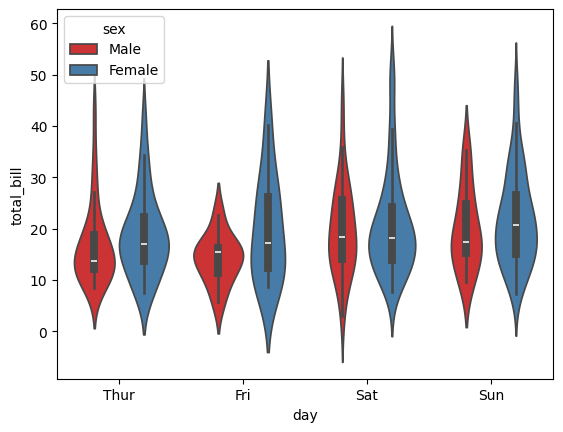

In [30]:
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',palette='Set1') # Split violin plots by sex

<Axes: xlabel='day', ylabel='total_bill'>

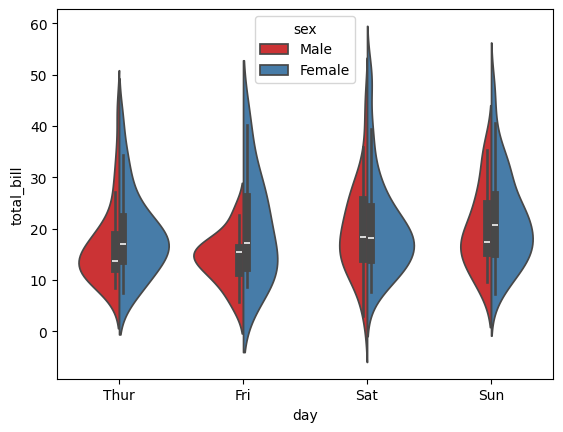

In [31]:
# Merge split violins into one for easier comparison
sns.violinplot(x="day", y="total_bill", data=tips,hue='sex',split=True,palette='Set1')

## stripplot and swarmplot
The stripplot will draw a scatterplot where one variable is categorical. A strip plot can be drawn on its own, but it is also a good complement to a box or violin plot in cases where you want to show all observations along with some representation of the underlying distribution.

The swarmplot is similar to stripplot(), but the points are adjusted (only along the categorical axis) so that they don’t overlap. This gives a better representation of the distribution of values, although it does not scale as well to large numbers of observations (both in terms of the ability to show all the points and in terms of the computation needed to arrange them).

/tmp/ipykernel_8038/2382556812.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow') # Draw scatter points based on category


<Axes: xlabel='day', ylabel='total_bill'>

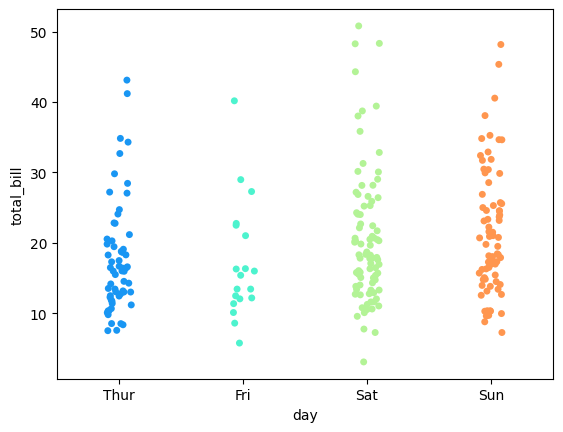

In [32]:
sns.stripplot(x="day", y="total_bill", data=tips, palette='rainbow') # Draw scatter points based on category

/tmp/ipykernel_8038/902749797.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow') # Add jitter to spread overlapping points


<Axes: xlabel='day', ylabel='total_bill'>

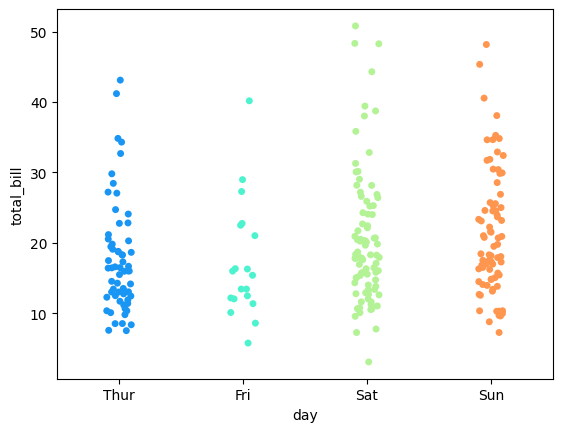

In [33]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True, palette='rainbow') # Add jitter to spread overlapping points

<Axes: xlabel='day', ylabel='total_bill'>

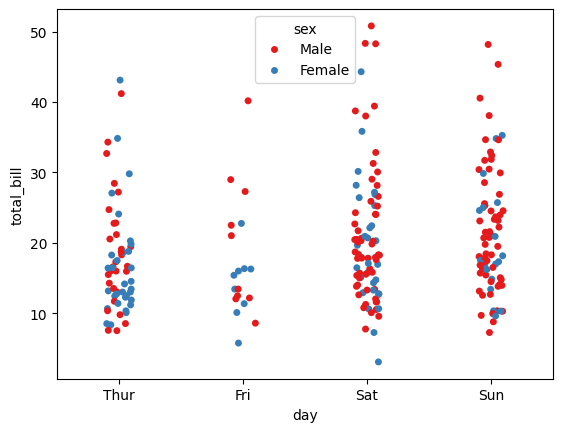

In [34]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1')# Split points by sex

<Axes: xlabel='day', ylabel='total_bill'>

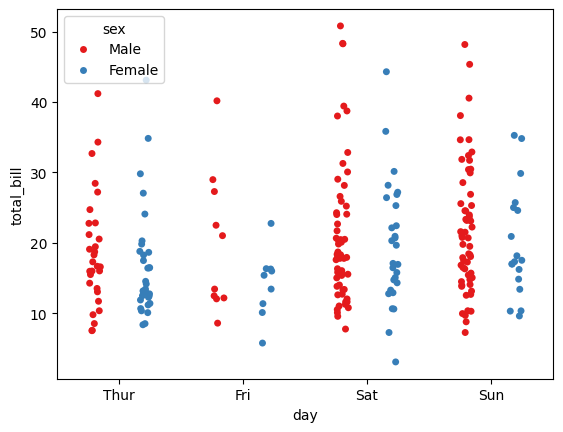

In [35]:
sns.stripplot(x="day", y="total_bill", data=tips,jitter=True,hue='sex',palette='Set1',dodge=True)

<Axes: xlabel='day', ylabel='total_bill'>

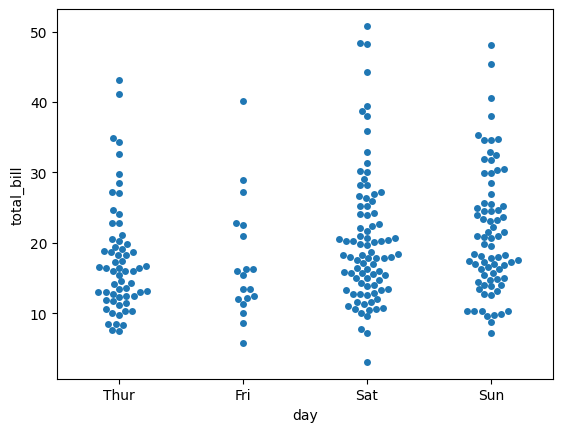

In [36]:
sns.swarmplot(x="day", y="total_bill", data=tips)# Create a swarm plot where points do not overlap

### Combining Categorical Plots

/tmp/ipykernel_8038/2083225568.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="tip", y="day", data=tips, palette='rainbow')


<Axes: xlabel='tip', ylabel='day'>

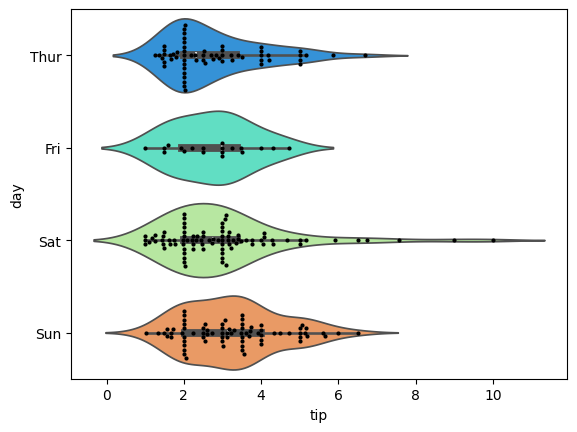

In [37]:
# Combine violin plot and swarm plot to show both density and data points
sns.violinplot(x="tip", y="day", data=tips, palette='rainbow')
sns.swarmplot(x="tip", y="day", data=tips, color='black', size=3)

## catplot

factorplot is the most general form of a categorical plot. It can take in a kind parameter to adjust the plot type:

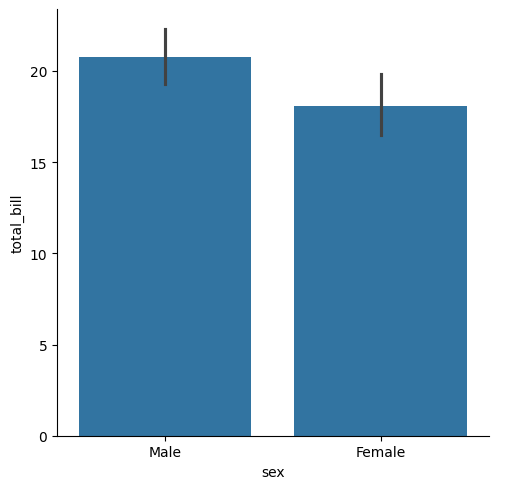

In [38]:
# General figure-level interface for drawing categorical plots
sns.catplot(x='sex', y='total_bill', data=tips, kind='bar')

# Matrix Plots

Matrix plots allow you to plot data as color-encoded matrices and can also be used to indicate clusters within the data (later in the machine learning section we will learn how to formally cluster data).

Let's begin by exploring seaborn's heatmap and clutermap:

In [39]:
import seaborn as sns
%matplotlib inline

In [40]:
flights = sns.load_dataset('flights') # Load Datasets

In [41]:
tips = sns.load_dataset('tips') # Load Datasets

In [42]:
tips.head() # first 5 rows

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [43]:
flights.head() # first 5 rows

,year,month,passengers
0,1949,Jan,112
1,1949,Feb,118
2,1949,Mar,132
3,1949,Apr,129
4,1949,May,121


## Heatmap

In order for a heatmap to work properly, your data should already be in a matrix form, the sns.heatmap function basically just colors it in for you. For example:

In [44]:
tips.head()# load dataset

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [46]:
# Calculate correlation for numeric columns only
tips.corr(numeric_only=True)

,total_bill,tip,size
total_bill,1.000000,0.675734,0.598315
tip,0.675734,1.000000,0.489299
size,0.598315,0.489299,1.000000


<Axes: >

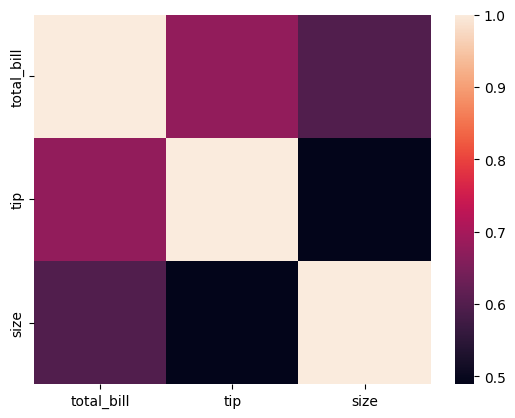

In [50]:
# Create heatmap using only numeric data for correlation
sns.heatmap(tips.corr(numeric_only=True))

<Axes: >

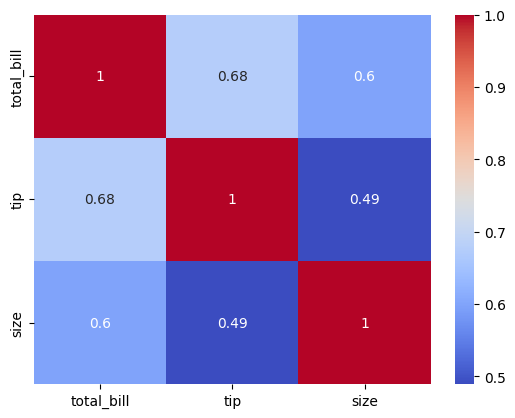

In [52]:
# Create a heatmap with a color map and values, using only numeric columns
sns.heatmap(tips.corr(numeric_only=True), cmap='coolwarm', annot=True)

Or for the flights data:

In [53]:
# Create a pivot table to reshape the data for a heatmap
flights.pivot_table(values='passengers',index='month',columns='year')

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112.0,115.0,145.0,171.0,196.0,204.0,242.0,284.0,315.0,340.0,360.0,417.0
Feb,118.0,126.0,150.0,180.0,196.0,188.0,233.0,277.0,301.0,318.0,342.0,391.0
Mar,132.0,141.0,178.0,193.0,236.0,235.0,267.0,317.0,356.0,362.0,406.0,419.0
Apr,129.0,135.0,163.0,181.0,235.0,227.0,269.0,313.0,348.0,348.0,396.0,461.0
May,121.0,125.0,172.0,183.0,229.0,234.0,270.0,318.0,355.0,363.0,420.0,472.0
Jun,135.0,149.0,178.0,218.0,243.0,264.0,315.0,374.0,422.0,435.0,472.0,535.0
Jul,148.0,170.0,199.0,230.0,264.0,302.0,364.0,413.0,465.0,491.0,548.0,622.0
Aug,148.0,170.0,199.0,242.0,272.0,293.0,347.0,405.0,467.0,505.0,559.0,606.0
Sep,136.0,158.0,184.0,209.0,237.0,259.0,312.0,355.0,404.0,404.0,463.0,508.0


<Axes: xlabel='year', ylabel='month'>

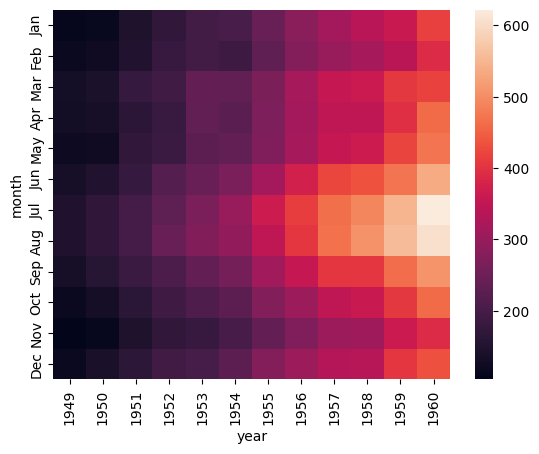

In [54]:
# Create the pivot table
pvflights = flights.pivot_table(values='passengers',index='month',columns='year')
# Generate the heatmap
sns.heatmap(pvflights)

<Axes: xlabel='year', ylabel='month'>

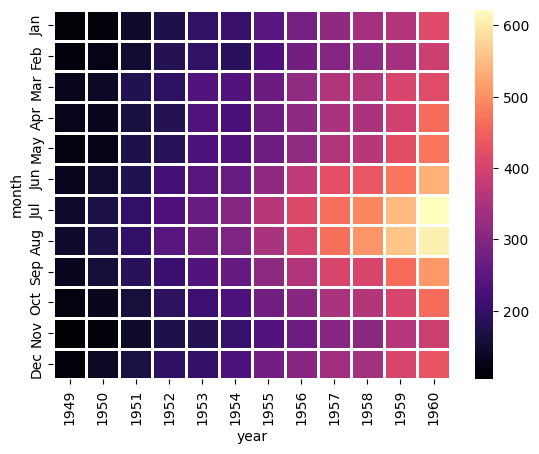

In [55]:
# Create a heatmap with 'magma' color map and white lines between cells
sns.heatmap(pvflights,cmap='magma',linecolor='white',linewidths=1)

## clustermap

The clustermap uses hierarchal clustering to produce a clustered version of the heatmap. For example:

In [57]:
# Hierarchically-clustered heatmap grouping similar months and years
sns.clustermap(pvflights)

RuntimeError: clustermap requires scipy to be available

Notice now how the years and months are no longer in order, instead they are grouped by similarity in value (passenger count). That means we can begin to infer things from this plot, such as August and July being similar (makes sense, since they are both summer travel months)

In [58]:
# More options to get the information a little clearer like normalization
sns.clustermap(pvflights,standard_scale=1)

RuntimeError: clustermap requires scipy to be available

# Regression Plots

Seaborn has many built-in capabilities for regression plots, however we won't really discuss regression until the machine learning section of the course, so we will only cover the **lmplot()** function for now.

**lmplot** allows you to display linear models, but it also conveniently allows you to split up those plots based off of features, as well as coloring the hue based off of features.

Let's explore how this works:

In [61]:
import seaborn as sns    # Load the seaborn visualization library
%matplotlib inline      # Ensure plots are rendered within the notebook

UsageError: unrecognized arguments: # Ensure plots are rendered within the notebook


In [67]:
tips = sns.load_dataset('tips') # load dataset

In [68]:
tips.head() # first 5 rows

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## lmplot()

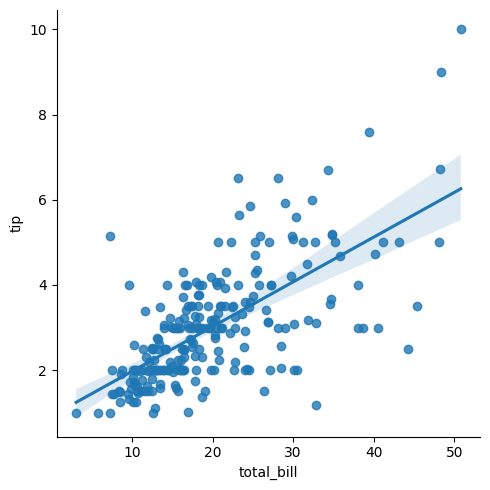

In [69]:
sns.lmplot(x='total_bill',y='tip',data=tips) # Create a scatter plot with a linear regression line

In [ ]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex') # Linear regression plot with data points colored by sex

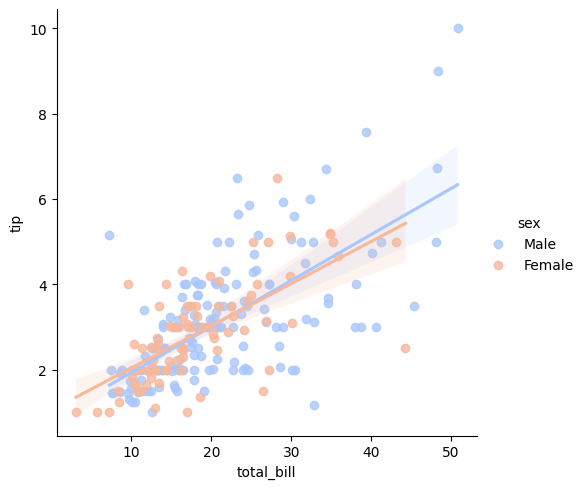

In [62]:
sns.lmplot(x='total_bill',y='tip',data=tips,hue='sex',palette='coolwarm') # Linear regression plot colored by sex with a specific color palette

## Using a Grid

We can add more variable separation through columns and rows with the use of a grid. Just indicate this with the col or row arguments:

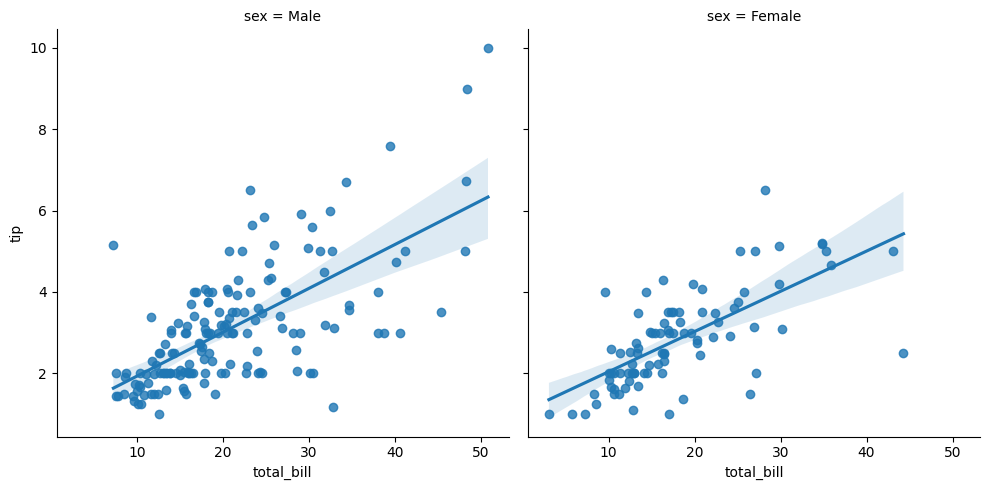

In [63]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='sex') # Create side-by-side linear regression plots for each sex

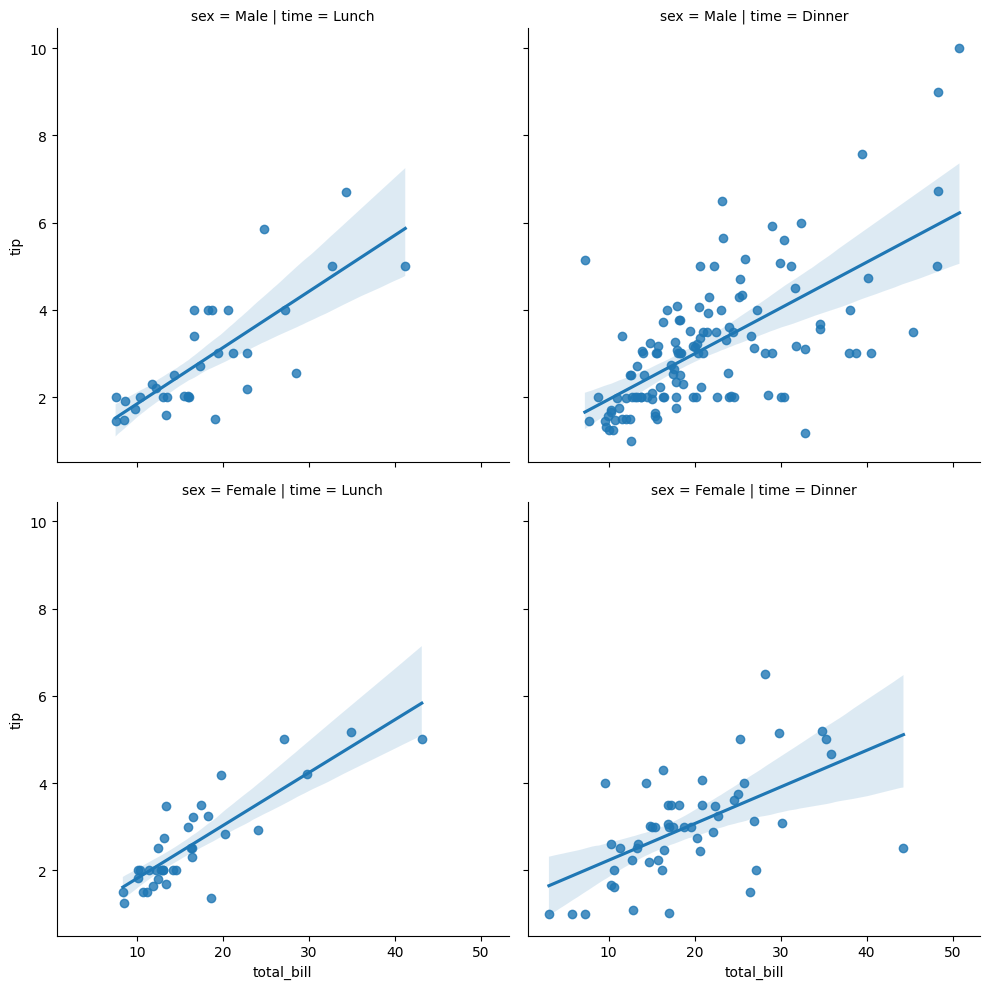

In [64]:
sns.lmplot(x="total_bill", y="tip", row="sex", col="time",data=tips) # Create a grid of regression plots split by sex 

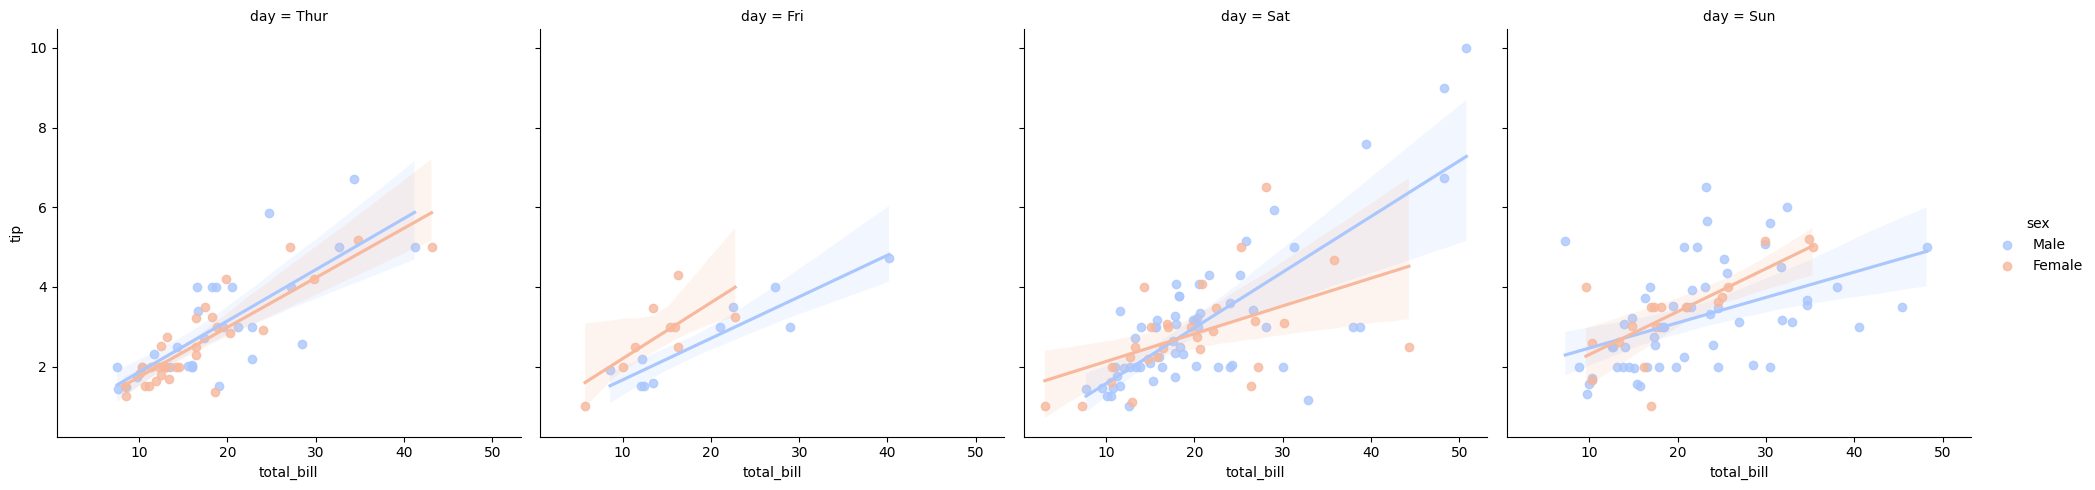

In [65]:
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm') # Grid of plots split by day (columns) and colored by sex

## Aspect and Size

Seaborn figures can have their size and aspect ratio adjusted with the **height** and **aspect** parameters:

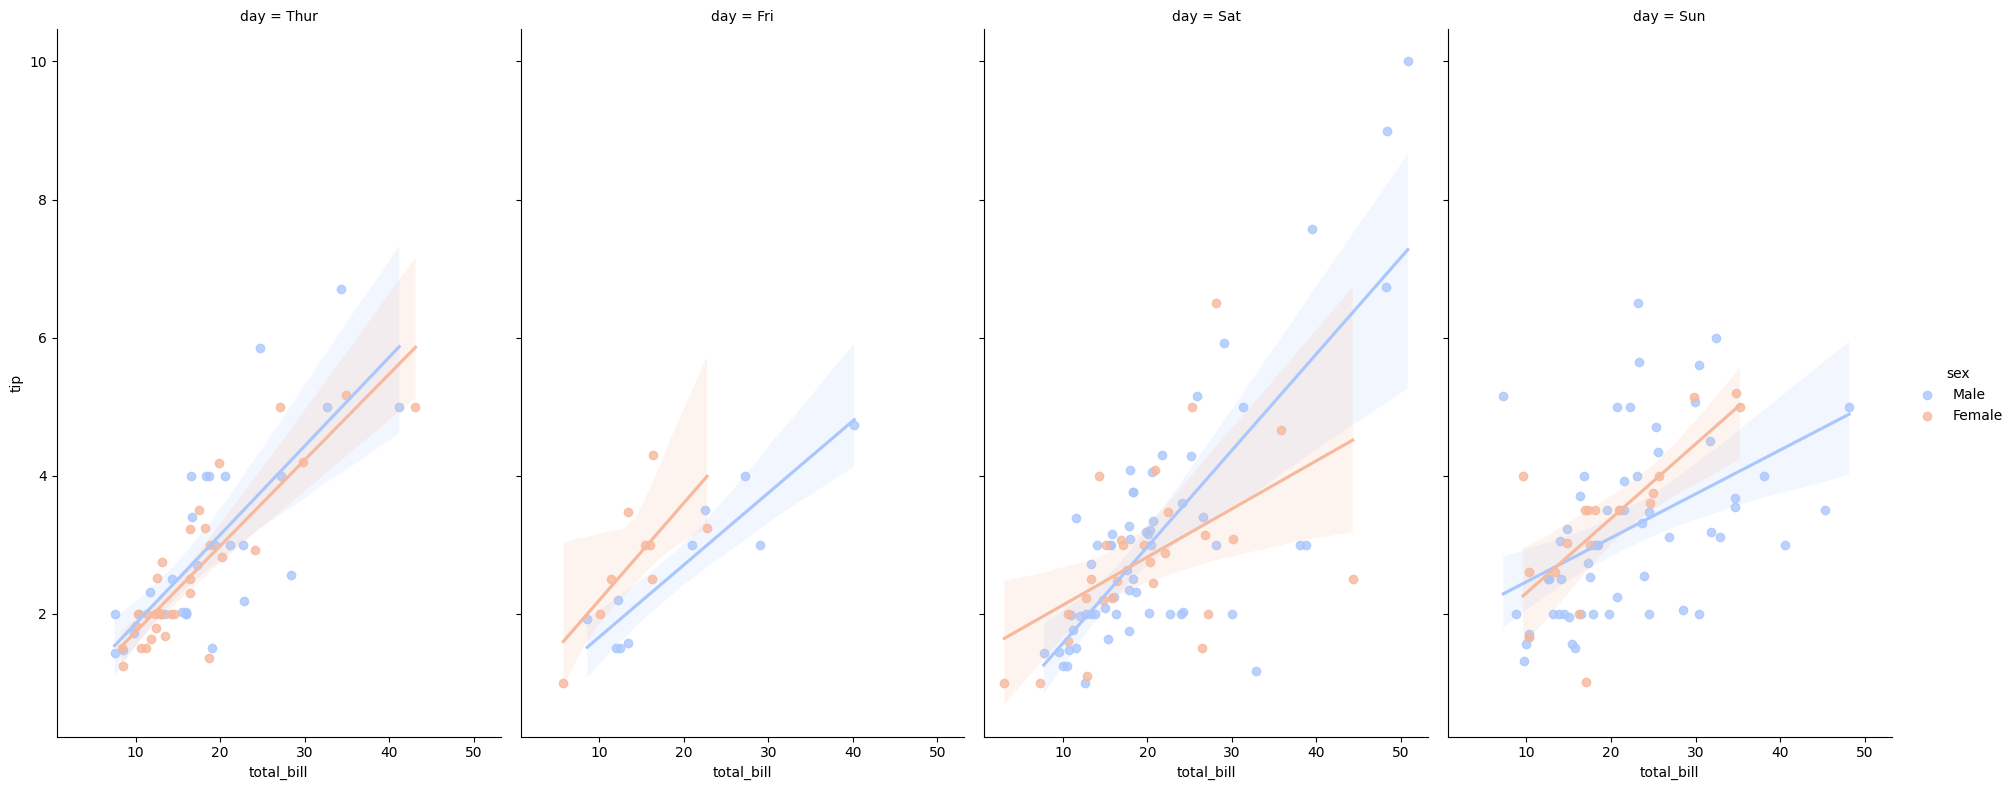

In [66]:
# Create a grid of regression plots with adjusted size and aspect ratio
# height: vertical size of each facet (in inches)
# aspect: width-to-height ratio for each facet
sns.lmplot(x='total_bill',y='tip',data=tips,col='day',hue='sex',palette='coolwarm',
          aspect=0.6,height=8)

### Reference:

* https://seaborn.pydata.org/ - Seaborn: statistical data visualization


* https://seaborn.pydata.org/tutorial/color_palettes.html - Color palettes